# EDA Overview – Credit Card Fraud Detection
Author: Trần Đăng Khoa  
Role: Tổng quan & Cấu trúc dữ liệu  
## Mục tiêu
- Hiểu cấu trúc dataset
- Kiểm tra kích thước dữ liệu
- Kiểm tra missing values
- Phân tích sự mất cân bằng lớp (Fraud vs Legit)

In [3]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
# Load dữ liệu
df = pd.read_csv("../../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Load Dataset

Dataset được tải từ file `creditcard.csv` bằng thư viện pandas.

- Dữ liệu gồm các giao dịch thẻ tín dụng.
- Các biến V1–V28 là các đặc trưng đã được biến đổi bằng kỹ thuật PCA để bảo mật thông tin.
- `Time`: thời gian giao dịch.
- `Amount`: số tiền của giao dịch.
- `Class`: biến mục tiêu (0 = không gian lận, 1 = gian lận).

Sau khi load dữ liệu, sử dụng `df.head()` để hiển thị 5 dòng đầu tiên nhằm kiểm tra cấu trúc và định dạng dữ liệu.

In [5]:
# Kiểm tra kích thước dữ liệu
print("Số dòng và cột:", df.shape)

Số dòng và cột: (284807, 31)


Dataset gồm 284,807 giao dịch và 31 biến.

Trong đó:
- 30 biến đầu là các đặc trưng đầu vào (Time, V1–V28, Amount).
- 1 biến mục tiêu là Class dùng để phân loại giao dịch gian lận hay không.

Số lượng dữ liệu lớn giúp mô hình học được nhiều đặc điểm quan trọng.

## Data Types & Missing Values

Sử dụng `df.info()` để kiểm tra:

- Số lượng cột và kiểu dữ liệu của từng biến
- Số lượng giá trị không bị thiếu (Non-Null Count)
- Tổng dung lượng bộ nhớ của dataset

In [6]:
# Kiểu dữ liệu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### Nhận xét:

- Dataset gồm 31 cột và 284,807 dòng.
- Tất cả các cột đều có 284,807 giá trị non-null → Không có dữ liệu bị thiếu (missing values).
- 30 biến có kiểu dữ liệu float64.
- 1 biến mục tiêu `Class` có kiểu int64.
- Dataset chiếm khoảng 67.4 MB bộ nhớ.

## Missing Values Analysis

Kiểm tra số lượng giá trị thiếu trong từng cột bằng hàm `isnull().sum()`.

In [7]:
# Kiểm tra missing values
df.isnull().sum().sort_values(ascending=False)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Nhận xét

Tất cả các cột đều có 0 giá trị thiếu.

Điều này cho thấy dataset hoàn chỉnh và không cần thực hiện bước xử lý missing values.

## Duplicate Records Analysis

Kiểm tra số lượng dòng dữ liệu bị trùng lặp trong dataset bằng hàm `duplicated().sum()`.

In [8]:
# Kiểm tra trùng lặp
df.duplicated().sum()

np.int64(1081)

### Nhận xét

Dataset có 1081 dòng bị trùng lặp.

Các bản ghi trùng lặp có thể ảnh hưởng đến kết quả phân tích và mô hình học máy,
do đó nên được loại bỏ trước khi tiếp tục các bước xử lý tiếp theo.

In [9]:
df = df.drop_duplicates()
print("Kích thước sau khi loại bỏ trùng:", df.shape)

Kích thước sau khi loại bỏ trùng: (283726, 31)


### After Removing Duplicates

Sau khi loại bỏ 1,081 bản ghi trùng lặp, dataset còn lại 283,726 dòng và 31 cột.

Việc loại bỏ các dòng trùng giúp:
- Đảm bảo tính chính xác của phân tích
- Tránh làm sai lệch phân phối dữ liệu
- Giảm nguy cơ overfitting khi xây dựng mô hình

In [10]:
# Kiểm tra phân bố Class (imbalance)
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

## Class Distribution Analysis

Sau khi loại bỏ các bản ghi trùng lặp, phân bố của biến mục tiêu (Class) như sau:

- Class 0 (Non-Fraud): 283,253 giao dịch
- Class 1 (Fraud): 473 giao dịch

Tỷ lệ gian lận chỉ chiếm khoảng 0.17% tổng số giao dịch,
trong khi giao dịch hợp lệ chiếm hơn 99.8%.

### Imbalance Analysis

Dataset bị mất cân bằng nghiêm trọng (severely imbalanced).

Số lượng giao dịch gian lận rất nhỏ so với giao dịch bình thường.
Điều này có thể khiến mô hình học máy:

- Dự đoán thiên về lớp 0
- Có độ chính xác (accuracy) cao nhưng không phát hiện được gian lận
- Bỏ sót nhiều giao dịch fraud (low recall)

Vì vậy, trong bước xây dựng mô hình, cần xem xét các kỹ thuật xử lý mất cân bằng như:
- Class weighting
- Oversampling (SMOTE)
- Undersampling

In [11]:
# Tính phần trăm
df["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

### Tỷ lệ phần trăm các lớp

- Non-Fraud (Class 0): 99.83%
- Fraud (Class 1): 0.17%

Tỷ lệ giao dịch gian lận chỉ chiếm khoảng 0.17% tổng số giao dịch.

### Imbalance Analysis

Dataset bị mất cân bằng nghiêm trọng (severely imbalanced dataset).

Sự chênh lệch rất lớn giữa hai lớp có thể gây ra các vấn đề:

- Mô hình có thể đạt độ chính xác (accuracy) cao chỉ bằng cách dự đoán tất cả là Class 0.
- Khả năng phát hiện gian lận (Recall của Class 1) có thể rất thấp.
- Cần sử dụng các thước đo phù hợp như Precision, Recall, F1-score và ROC-AUC thay vì chỉ dùng Accuracy.

Do đó, trong bước xây dựng mô hình, cần cân nhắc các kỹ thuật xử lý dữ liệu mất cân bằng như:
- Class weighting
- Oversampling (SMOTE)
- Undersampling

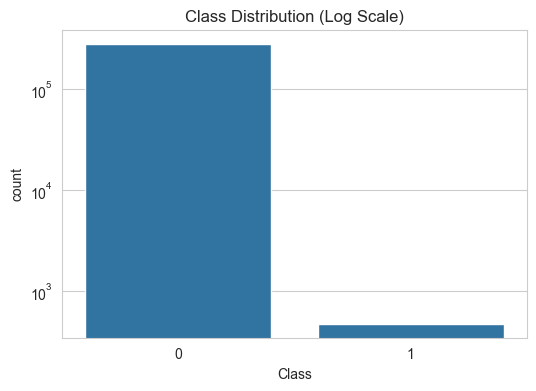

In [15]:
# Vẽ biểu đồ

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.yscale("log")
plt.title("Class Distribution (Log Scale)")
plt.show()

### Nhận xét

Biểu đồ cho thấy sự mất cân bằng nghiêm trọng giữa hai lớp.
Class 0 (Non-Fraud) chiếm gần như toàn bộ dataset,
trong khi Class 1 (Fraud) chỉ chiếm khoảng 0.17%.

Điều này khẳng định đây là một bài toán classification
với dữ liệu mất cân bằng mạnh (severely imbalanced dataset).

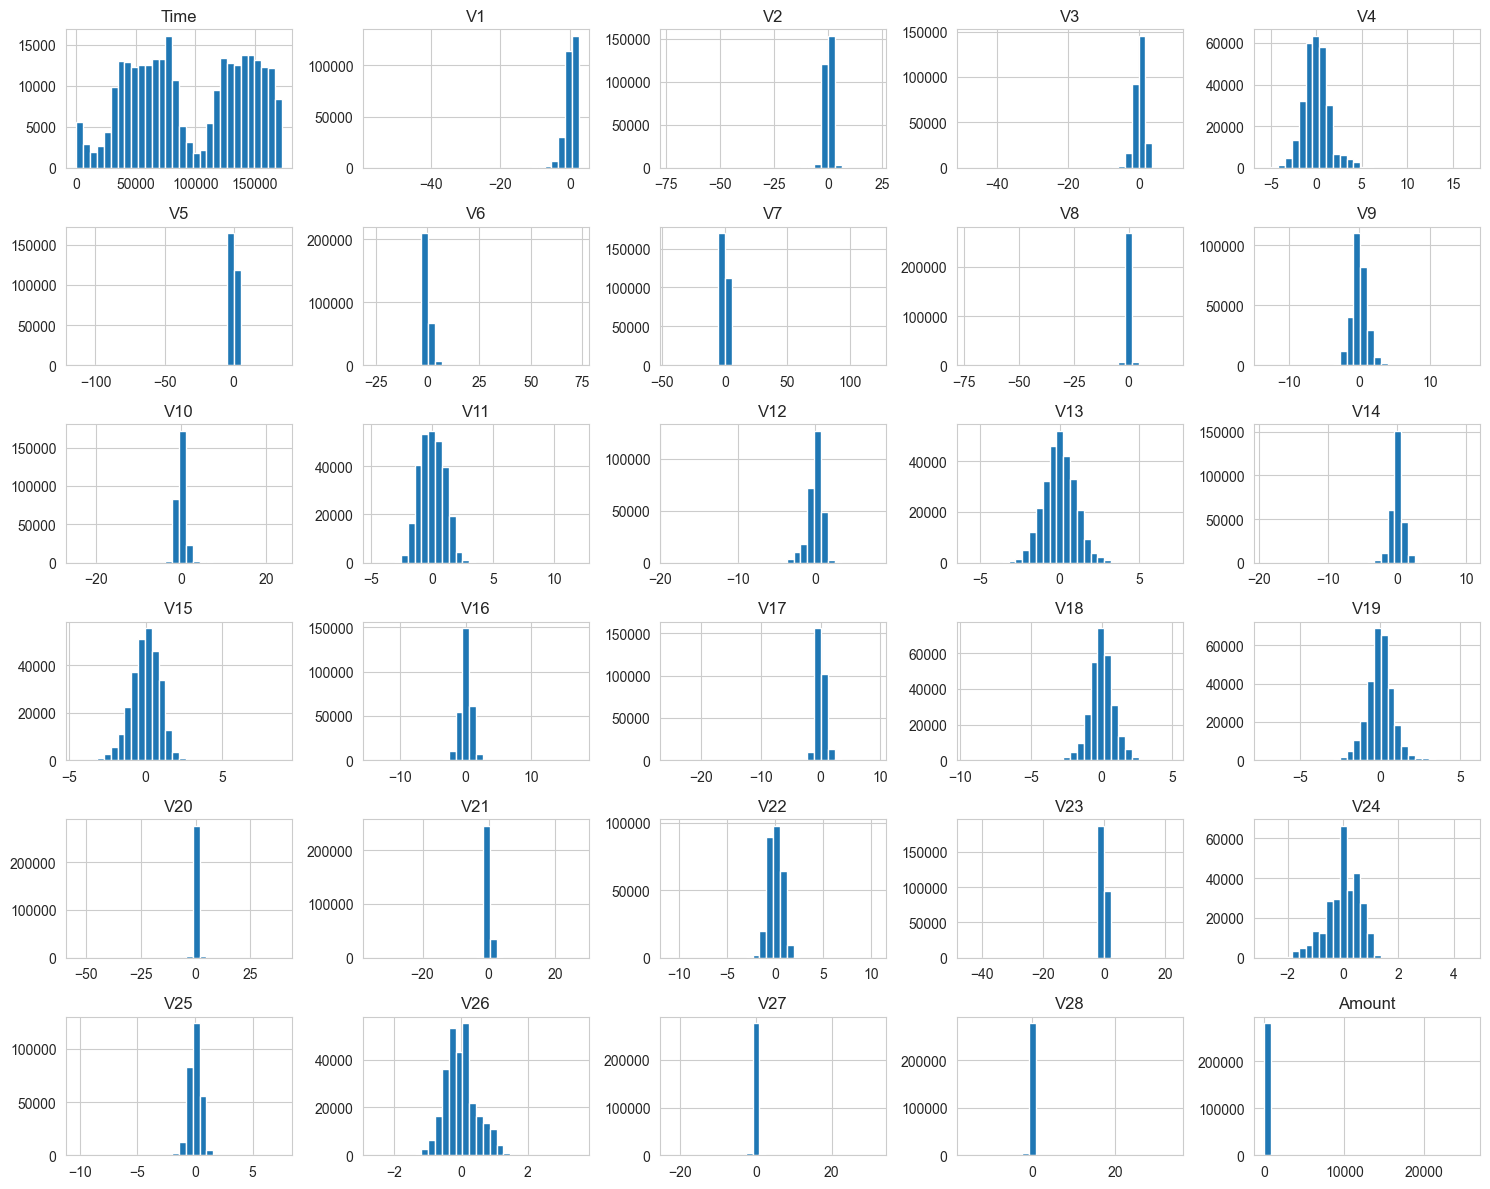

In [16]:
numeric_cols = df.drop("Class", axis=1).columns

df[numeric_cols].hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

## Phân phối các biến số

Biểu đồ histogram cho thấy phân phối của các biến Time, Amount và các biến V1–V28.

### Nhận xét:

- Các biến V1–V28 có dạng phân phối gần chuẩn và tập trung quanh 0.
- Điều này là do các biến này đã được biến đổi bằng PCA (Principal Component Analysis).
- Một số biến có đuôi dài (long tail), cho thấy sự tồn tại của outliers.
- Biến Amount có phân phối lệch phải (right-skewed), nhiều giao dịch nhỏ và một số ít giao dịch rất lớn.
- Biến Time phân bố tương đối đồng đều theo thời gian giao dịch.

### Kết luận:

- Các biến PCA đã được chuẩn hóa tốt.
- Amount có thể cần scaling (StandardScaler hoặc RobustScaler) trước khi đưa vào mô hình.
- Không phát hiện giá trị bất thường nghiêm trọng ở các biến PCA.

In [17]:
# Thống kê mô tả
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


## Thống kê mô tả (Descriptive Statistics)

Bảng thống kê cho thấy:

### 1. Số lượng quan sát
- Tổng số giao dịch: 283,726
- Không có giá trị thiếu (missing values) trong dataset.

### 2. Các biến V1–V28
- Mean ≈ 0
- Phân phối khá đối xứng quanh 0
- Có một số giá trị cực trị (min/max lớn) → tồn tại outliers
- Điều này phù hợp vì các biến đã được biến đổi bằng PCA.

### 3. Biến Time
- Phạm vi: 0 → 172,792
- Phân bố theo thứ tự thời gian giao dịch
- Có thể không mang nhiều ý nghĩa trực tiếp cho mô hình nếu không feature engineering thêm.

### 4. Biến Amount
- Mean ≈ 88.47
- Max ≈ 25,691
- Phân phối lệch phải (right-skewed)
- Có nhiều giao dịch nhỏ và một số giao dịch giá trị lớn
- Nên được chuẩn hóa trước khi đưa vào mô hình

### 5. Biến Class
- Mean ≈ 0.001667 (~0.17%)
- Xác nhận dataset mất cân bằng nghiêm trọng

In [18]:
# Kiểm tra imbalance ratio
fraud_count = df["Class"].value_counts()[1]
normal_count = df["Class"].value_counts()[0]

print("Fraud ratio:", fraud_count / normal_count)

Fraud ratio: 0.0016698852262818046


## Imbalance Ratio

Fraud ratio = 0.00167

Điều này có nghĩa là:
- Cứ 1 giao dịch gian lận thì có khoảng 600 giao dịch bình thường.
- Tỷ lệ xấp xỉ 1 : 599.

=> Dataset bị mất cân bằng nghiêm trọng (extreme class imbalance).

# EDA Conclusion

Sau quá trình phân tích dữ liệu:

1. Dataset đã được làm sạch và loại bỏ các bản ghi trùng lặp.
2. Không tồn tại giá trị thiếu (missing values).
3. Các biến V1–V28 đã được chuẩn hóa thông qua PCA và có phân phối gần chuẩn.
4. Biến Amount có phân phối lệch phải và cần được scaling trước khi huấn luyện mô hình.
5. Dataset bị mất cân bằng nghiêm trọng với tỷ lệ fraud chỉ khoảng 0.17% (~1:599).

Do đó, trong bước xây dựng mô hình:
- Cần sử dụng các metric phù hợp như Precision, Recall, F1-score, PR-AUC.
- Cần áp dụng kỹ thuật xử lý imbalance (class_weight, SMOTE hoặc threshold tuning).